Import Libraries

In [1]:
import jax
import flax
import optax
from jax import lax, random, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from flax import linen as nn
from evojax.util import get_params_format_fn

import time
import numpy as np
import pandas as pd
from scipy import io
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import minimize
from scipy.optimize import minimize_scalar
from matplotlib import rcParams 

import matplotlib.ticker as ticker

import math
# config = {
#     "font.family": 'Times New Roman',
#     "font.size": 14,
#     "mathtext.fontset": 'stix',
#     "font.serif": ['SimSun'],
# }
# rcParams.update(config)

# rcParams['axes.unicode_minus'] = False
# choose GPU
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
#jax.config.update("jax_enable_x64", True)
jax.config.update("jax_default_matmul_precision", "highest")

In [2]:
# parameter
Re = 40

In [3]:
sim = pd.read_csv('flow_past_square_three_880x164_RE40.csv',sep=',')
print("x: ", sim['x'].shape, ", y: " , sim['y'].shape,", u: ", sim['u'].shape, ", v: " , sim['v'].shape, "p: ", sim['p'].shape)

x:  (146412,) , y:  (146412,) , u:  (146412,) , v:  (146412,) p:  (146412,)


In [4]:
sim

,x,y,u,v,p,Unnamed: 5
0,0.0000,0.0,0.000000e+00,0.0,2.217940,NaN
1,0.0125,0.0,0.000000e+00,0.0,2.217940,NaN
2,0.0375,0.0,0.000000e+00,0.0,2.217580,NaN
3,0.0625,0.0,0.000000e+00,0.0,2.217270,NaN
4,0.0875,0.0,0.000000e+00,0.0,2.217010,NaN
...,...,...,...,...,...,...
146407,21.9125,4.1,-1.705640e-16,0.0,-0.020983,NaN
146408,21.9375,4.1,-1.705640e-16,0.0,-0.021707,NaN
146409,21.9625,4.1,-1.705640e-16,0.0,-0.022430,NaN
146410,21.9875,4.1,-1.705640e-16,0.0,-0.023153,NaN


In [5]:
sim_x = sim['x'].values.reshape(-1,1)
sim_y = sim['y'].values.reshape(-1,1)
sim_u = sim['u'].values.reshape(-1,1)
sim_v = sim['v'].values.reshape(-1,1)
sim_p = sim['p'].values.reshape(-1,1)


In [6]:
x_l, x_u, y_l, y_u = np.min(sim_x), np.max(sim_x), np.min(sim_y), np.max(sim_y)

ext = [x_l, x_u, y_l, y_u]
print (x_l, x_u, y_l, y_u)


0.0 22.0 0.0 4.1


In [7]:
data_X, data_Y = np.hstack([sim_x, sim_y]), np.hstack([sim_u, sim_v, sim_p])
data_X

array([[0.00000e+00, 0.00000e+00],
       [1.25000e-02, 0.00000e+00],
       [3.75000e-02, 0.00000e+00],
       ...,
       [2.19625e+01, 4.10000e+00],
       [2.19875e+01, 4.10000e+00],
       [2.20000e+01, 4.10000e+00]])

In [8]:
data_Y

array([[ 0.00000e+00,  0.00000e+00,  2.21794e+00],
       [ 0.00000e+00,  0.00000e+00,  2.21794e+00],
       [ 0.00000e+00,  0.00000e+00,  2.21758e+00],
       ...,
       [-1.70564e-16,  0.00000e+00, -2.24300e-02],
       [-1.70564e-16,  0.00000e+00, -2.31532e-02],
       [-1.70564e-16,  0.00000e+00, -2.31532e-02]])

In [9]:
x_unique, y_unique = np.unique(sim_x), np.unique(sim_y)

dx = 0.025
dy = 0.025
print ('dx:',dx, 'dy:',dy)
print ( 'x_unique shape: ', x_unique.shape)
print ( 'y_unique shape: ', y_unique.shape)

dx: 0.025 dy: 0.025
x_unique shape:  (882,)
y_unique shape:  (166,)


In [10]:
data_X.shape


(146412, 2)

In [11]:
square_xy_center = np.array([[2.0, 2.0],[4.0,2.5],[6,1.5]])
square_length = 1
half_length = square_length/2

n_per_edge = 39  

all_square_bc_point = []

for cx, cy in square_xy_center:
    x_left = cx - half_length
    x_right = cx + half_length
    y_bottom = cy - half_length
    y_top = cy + half_length

    x_vals = np.linspace(x_left + dx/2, x_right- dx/2, n_per_edge)
    y_vals = np.linspace(y_bottom+ dy/2, y_top- dy/2, n_per_edge)

    bottom = np.column_stack([x_vals, np.full_like(x_vals, y_bottom)])
    top    = np.column_stack([x_vals, np.full_like(x_vals, y_top)])
    left   = np.column_stack([np.full_like(y_vals, x_left), y_vals])
    right  = np.column_stack([np.full_like(y_vals, x_right), y_vals])

    boundary = np.vstack([bottom, top, left, right])
    all_square_bc_point.append(boundary)

data_X_square = np.vstack(all_square_bc_point) 
data_Y_square = np.zeros((data_X_square.shape[0], 3))
print(data_X_square.shape) 
print(data_Y_square.shape) 


(468, 2)
(468, 3)


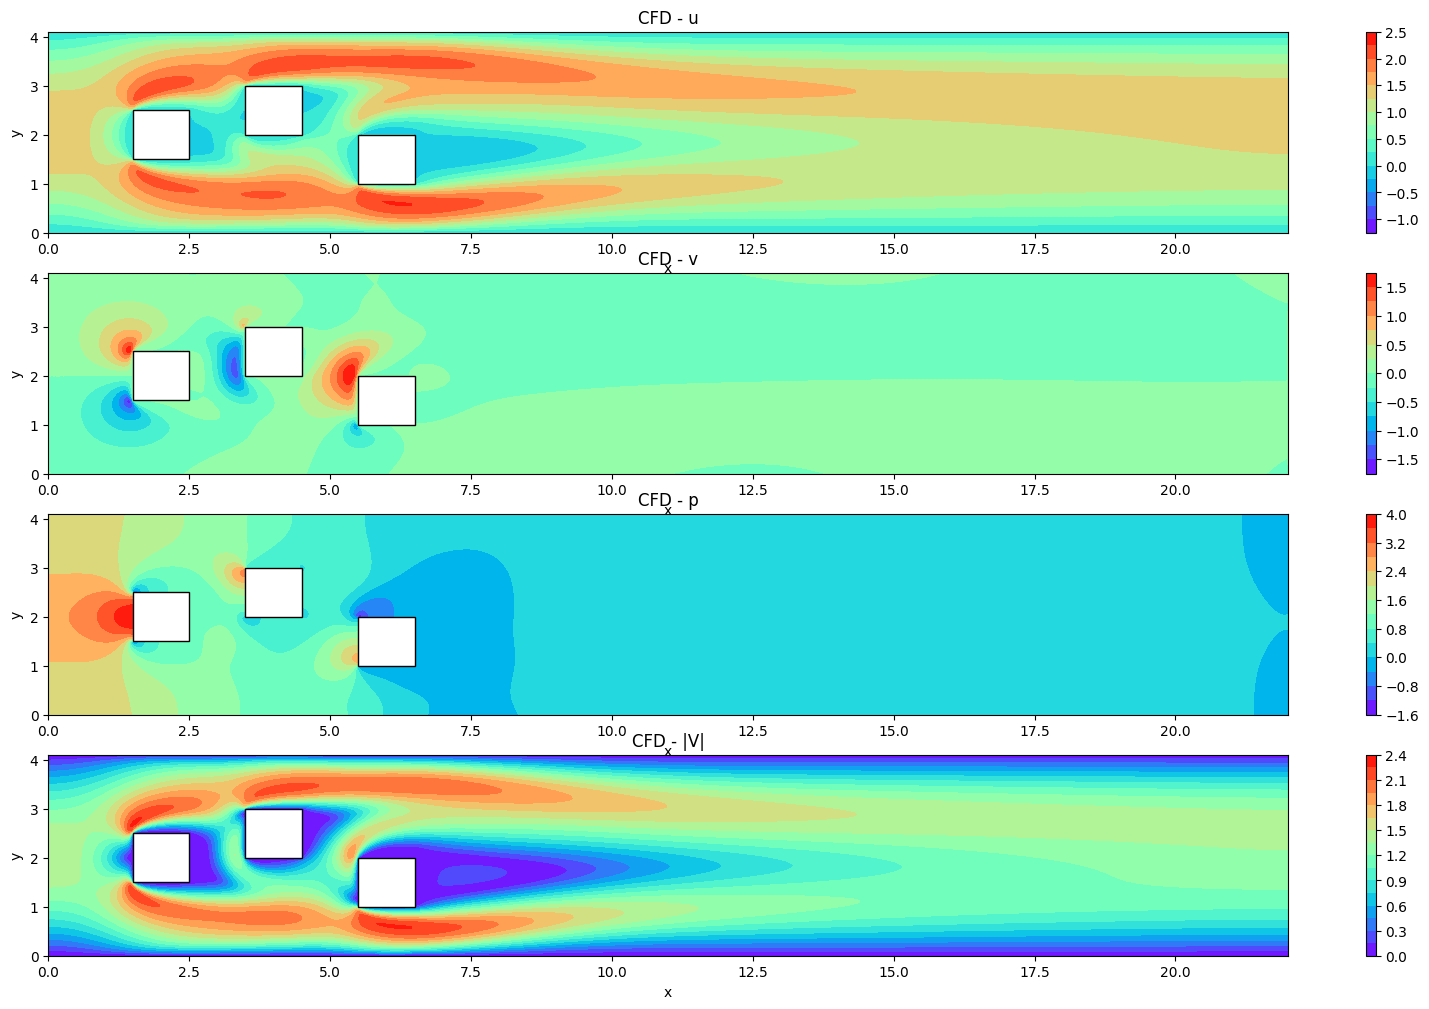

In [12]:
magnitude_V = np.sqrt(data_Y[:,0]**2 + data_Y[:,1]**2)
con_lv = 15

def draw_squares(ax, centers, half_length, color='white'):
    for cx, cy in centers:
        x = [cx - half_length, cx + half_length, cx + half_length, cx - half_length]
        y = [cy - half_length, cy - half_length, cy + half_length, cy + half_length]
        ax.fill(x, y, color=color, edgecolor='black', linewidth=1.0)


fig = plt.figure(figsize=(20, 12))

ax = fig.add_subplot(4, 1, 1)
cf = ax.tricontourf(data_X[:, 0], data_X[:, 1], data_Y[:, 0],
                    con_lv, origin='lower', cmap='rainbow', extent=ext)
draw_squares(ax, square_xy_center, half_length)
ax.set_xlim(x_l, x_u)
ax.set_ylim(y_l, y_u)
# ax.set_aspect('equal')
plt.colorbar(cf, ax=ax)
ax.set_title('CFD - u')
ax.set_xlabel('x')
ax.set_ylabel('y')

ax = fig.add_subplot(4, 1, 2)
cf = ax.tricontourf(data_X[:, 0], data_X[:, 1], data_Y[:, 1],
                    con_lv, origin='lower', cmap='rainbow', extent=ext)
draw_squares(ax, square_xy_center, half_length)
ax.set_xlim(x_l, x_u)
ax.set_ylim(y_l, y_u)
# ax.set_aspect('equal')
plt.colorbar(cf, ax=ax)
ax.set_title('CFD - v')
ax.set_xlabel('x')
ax.set_ylabel('y')

ax = fig.add_subplot(4, 1, 3)
cf = ax.tricontourf(data_X[:, 0], data_X[:, 1], data_Y[:, 2],
                    con_lv, origin='lower', cmap='rainbow', extent=ext)
draw_squares(ax, square_xy_center, half_length)
ax.set_xlim(x_l, x_u)
ax.set_ylim(y_l, y_u)
# ax.set_aspect('equal')
plt.colorbar(cf, ax=ax)
ax.set_title('CFD - p')
ax.set_xlabel('x')
ax.set_ylabel('y')

ax = fig.add_subplot(4, 1, 4)
cf = ax.tricontourf(data_X[:, 0], data_X[:, 1], magnitude_V,
                    con_lv, origin='lower', cmap='rainbow', extent=ext)
draw_squares(ax, square_xy_center, half_length)
ax.set_xlim(x_l, x_u)
ax.set_ylim(y_l, y_u)
# ax.set_aspect('equal')
plt.colorbar(cf, ax=ax)
ax.set_title('CFD - |V|')
ax.set_xlabel('x')
ax.set_ylabel('y')

# plt.tight_layout()
plt.show()


In [13]:
print("data_X shape: ", data_X.shape, "data_Y shape: ", data_Y.shape)

data_X shape:  (146412, 2) data_Y shape:  (146412, 3)


In [14]:
inside_any_square = np.zeros(len(data_X), dtype=bool)

for center in square_xy_center:
    cx, cy = center
    in_square = (
        (data_X[:, 0] >= cx - half_length) & (data_X[:, 0] <= cx + half_length) &
        (data_X[:, 1] >= cy - half_length) & (data_X[:, 1] <= cy + half_length)
    )
    inside_any_square |= in_square  

data_X_outside = data_X[~inside_any_square]
data_Y_outside = data_Y[~inside_any_square]

In [15]:
data_X_outside.shape

(141612, 2)

In [16]:
def is_outside_square(points, centers, half_length):
    mask = np.ones(len(points), dtype=bool)
    for (cx, cy) in centers:
        in_square = (
            (points[:, 0] >= cx - half_length) & (points[:, 0] <= cx + half_length) &
            (points[:, 1] >= cy - half_length) & (points[:, 1] <= cy + half_length)
        )
        mask &= ~in_square  
    return mask

shifts = np.array([
    [0, 0],        
    [dx, 0],      
    [-dx, 0],      
    [0, dy],      
    [0, -dy],
    [ dx,  dy],
    [-dx,  dy],
    [ dx , -dy],
    [ -dx , -dy],
])

N = data_X.shape[0]
all_neighbors = (data_X[:, None, :] + shifts[None, :, :]).reshape(-1, 2)

outside_mask_flat = is_outside_square(all_neighbors, square_xy_center, half_length)
outside_mask = outside_mask_flat.reshape(N, 9)

valid_mask = np.all(outside_mask, axis=1)

data_X_PDE = data_X[valid_mask]
data_Y_PDE = data_Y[valid_mask]

In [17]:
def is_inside_square(points, centers, half_length):
    mask = np.zeros(len(points), dtype=bool)
    for (cx, cy) in centers:
        in_box = (
            (points[:, 0] >= cx - half_length) & (points[:, 0] <= cx + half_length) &
            (points[:, 1] >= cy - half_length) & (points[:, 1] <= cy + half_length)
        )
        mask |= in_box
    return mask

shifts = np.array([
    [ dx,  0],
    [-dx,  0],
    [ 0 , dy],
    [ 0 , -dy],
    [ dx,  dy],
    [-dx,  dy],
    [ dx , -dy],
    [ -dx , -dy],
])

mask_self_outside = ~is_inside_square(data_X, square_xy_center, half_length)

N = data_X.shape[0]
neighbors = (data_X[:, None, :] + shifts[None, :, :]).reshape(-1, 2)

mask_neighbors_inside = is_inside_square(neighbors, square_xy_center, half_length).reshape(N, 8)

mask_neighbor_any_inside = np.any(mask_neighbors_inside, axis=1)

ad_mask = mask_self_outside & mask_neighbor_any_inside
data_X_ad = data_X[ad_mask]
data_Y_ad = data_Y[ad_mask]


In [18]:
bc_lrtb_mask = (
    (data_X_PDE[:, 0] == x_l) |
    (data_X_PDE[:, 0] == x_u) |
    (data_X_PDE[:, 1] == y_l) |
    (data_X_PDE[:, 1] == y_u)
)

data_X_BC = data_X_PDE[bc_lrtb_mask]
data_Y_BC = data_Y_PDE[bc_lrtb_mask]
print("data_X_BC", data_X_BC.shape)
print("data_Y_BC", data_Y_BC.shape)

data_X_PDE = data_X_PDE[~bc_lrtb_mask]
data_Y_PDE = data_Y_PDE[~bc_lrtb_mask]

print("data_X_PDE", data_X_PDE.shape)
print("data_Y_PDE", data_Y_PDE.shape)

data_X_BC (2092, 2)
data_Y_BC (2092, 3)
data_X_PDE (139028, 2)
data_Y_PDE (139028, 3)


In [19]:
# convert to jnp
data_X_PDE, data_Y_PDE= jnp.array(data_X_PDE), jnp.array(data_Y_PDE) 
data_X_BC, data_Y_BC = jnp.array(data_X_BC), jnp.array(data_Y_BC)
data_X_ad, data_Y_ad = jnp.array(data_X_ad), jnp.array(data_Y_ad)
data_X_square, data_Y_square = jnp.array(data_X_square), jnp.array(data_Y_square)


print("data_X_PDE shape: ", data_X_PDE.shape, "data_Y_PDE shape: ", data_Y_PDE.shape)
print("data_X_BC shape: ", data_X_BC.shape, "data_Y_BC shape: ", data_Y_BC.shape)
print("data_X_ad shape: ", data_X_ad.shape, "data_Y_ad shape: ", data_Y_ad.shape)
print("data_X_square shape: ", data_X_square.shape, "data_Y_square shape: ", data_Y_square.shape)


data_X_PDE shape:  (139028, 2) data_Y_PDE shape:  (139028, 3)
data_X_BC shape:  (2092, 2) data_Y_BC shape:  (2092, 3)
data_X_ad shape:  (492, 2) data_Y_ad shape:  (492, 3)
data_X_square shape:  (468, 2) data_Y_square shape:  (468, 3)


In [20]:
# batch size
BS_PDE = int(len(data_X_PDE)*0.1)
BS_BC = int(len(data_X_BC)*0.1)
BS_square_BC = int(len(data_X_square)*0.1)
BS_AD = int(len(data_X_ad)*0.1)

BS_ALL = BS_PDE + BS_BC + BS_square_BC + BS_AD
n_pde, n_BC, n_square, n_ad = len(data_X_PDE), len(data_X_BC), len(data_X_square), len(data_X_ad)
n_all = n_pde + n_BC + n_square + n_ad

print('The total number of samples:')
print('n_all: ',n_all, 'n_pde: ',n_pde, 'n_BC: ',n_BC, 'n_ad: ',n_ad, 'n_square: ',n_square)
print('The number of samples in each batch:')
print('BS_ALL: ',BS_ALL, 'BS_PDE: ',BS_PDE, 'BS_BC: ',BS_BC, 'BS_square_BC: ',BS_square_BC, 'BS_AD: ',BS_AD)


The total number of samples:
n_all:  142080 n_pde:  139028 n_BC:  2092 n_ad:  492 n_square:  468
The number of samples in each batch:
BS_ALL:  14206 BS_PDE:  13902 BS_BC:  209 BS_square_BC:  46 BS_AD:  49


DNN / PINN   

In [21]:
nn_acf = nn.silu
class PINN(nn.Module):
    """PINNs"""
    def setup(self):
        # initialization
        kinit = jax.nn.initializers.he_uniform()
        # feature mapping later
        self.feats = nn.Dense(n_nodes * 2, kernel_init = kinit)
        # hidden layers
        self.layers = [nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf]
        # split layers
        self.splitu = nn.Dense(n_nodes, kernel_init = kinit)
        self.layeru = [nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,                       
                       nn.Dense(1, kernel_init = kinit, use_bias=False),
                       ]
        self.splitv = nn.Dense(n_nodes, kernel_init = kinit)
        self.layerv = [nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,                       
                       nn.Dense(1, kernel_init = kinit, use_bias=False),
                       ]
        self.splitp = nn.Dense(n_nodes, kernel_init = kinit)      
        self.layerp = [nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,                       
                       nn.Dense(1, kernel_init = kinit, use_bias=False),
                       ]     



    @nn.compact
    def __call__(self, inputs):
        # split the two variables, probably just by slicing
        x, y = inputs[:,0:1], inputs[:,1:2]
         
        def get_uvp(x, y):

            inputs = jnp.hstack([x,y ])
            # feature mapping
            hidden = self.feats(inputs)
            hidden = jnp.sin(jnp.pi*hidden)
            # hidden = jnp.sin(hidden)

            # share hidden layer
            for i, lyr in enumerate(self.layers):
                hidden = lyr(hidden)
            # split hidden layer
            u = self.splitu(hidden)
            for i, lyr in enumerate(self.layeru):
                u = lyr(u)  
            v = self.splitv(hidden)
            for i, lyr in enumerate(self.layerv):
                v = lyr(v)   
            p = self.splitp(hidden)
            for i, lyr in enumerate(self.layerp):
                p = lyr(p) 

            return (u,v,p)  
    
        u, v, p = get_uvp(x, y)
        
        def u_inlet(y):
            Uref = 0.3
            numerator = 4 * Uref * y * 0.1 * (0.41 - y * 0.1)
            denominator = 0.41**2 * 0.2
            return numerator / denominator

        xE, xW = x + dx, x - dx
        yN, yS = y + dy, y - dy
        xe, xw = x + 0.5*dx, x - 0.5*dx
        yn, ys = y + 0.5*dy, y - 0.5*dy
        # obtain u, v, p neighbour
        uE, vE, pE= get_uvp(xE, y)
        uW, vW, pW= get_uvp(xW, y)
        uN, vN, pN= get_uvp(x, yN)
        uS, vS, pS= get_uvp(x, yS)
        ue, ve, pe= get_uvp(xe, y)
        uw, vw, pw= get_uvp(xw, y)
        un, vn, pn= get_uvp(x, yn)
        us, vs, ps= get_uvp(x, ys)
        
        vWbc = 0
        uNbc, vNbc = 0,0
        uSbc, vSbc = 0,0

         
        xB_E, xB_W = abs(xE-x_u)<0.01*dx, abs(xW-x_l)<0.01*dx
        yB_N, yB_S = abs(yN-y_u)<0.01*dy, abs(yS-y_l)<0.01*dy           
        # # direct forcing u & v values for xB_E, xB_W, yB_N, yB_S
        uW = jnp.where(xB_W, u_inlet(y), uW)
        vW = jnp.where(xB_W, vWbc, vW)
        uN, vN = jnp.where(yB_N, uNbc, uN), jnp.where(yB_N, vNbc, vN)
        uS, vS = jnp.where(yB_S, uSbc, uS), jnp.where(yB_S, vSbc, vS)
         
        xB_e, xB_w = abs(xe-x_u)<0.01*dx, abs(xw-x_l)<0.01*dx
        yB_n, yB_s = abs(yn-y_u)<0.01*dy, abs(ys-y_l)<0.01*dy           
        # direct forcing u & v values for xB_E, xB_W, yB_N, yB_S
        
        uw = jnp.where(xB_w, u_inlet(y), uw)
        vw = jnp.where(xB_w, vWbc, vw)
        un,vn = jnp.where(yB_n, uNbc, un), jnp.where(yB_n, vNbc, vn)
        us,vs = jnp.where(yB_s, uSbc, us), jnp.where(yB_s, vSbc, vs)
        
        ae = ue
        aw = -uw
        an = vn
        aas = -vs
        
        x_right_E = (x_u - dx)*jnp.ones_like(x)
        x_right_EE = x_u*jnp.ones_like(x)
        u_r_E,v_r_E,_ = get_uvp(x_right_E, y)
        u_r_EE,v_rEE,p_r_EE = get_uvp(x_right_EE, y)
        niu = 1/Re
        u_r_bc = -(u_r_E - u_r_EE )/ dx *niu - p_r_EE
        v_r_bc = v_r_E  - v_rEE
        
        x_left_W = x_l *jnp.ones_like(x)
        u_l_W,_,_ = get_uvp(x_left_W, y)
        u_l_bc = u_l_W - u 
               
        source_x = (pe - pw)
        source_y = (pn - ps) 

        bc  = (x == x_l) | (x == x_u) | (y == y_l) | (y == y_u)
        nbc = (~bc)
        l_bc = (x == x_l)
        tb_bc = (y == y_u) | (y == y_l)        
        r_bc = (x == x_u)
        
        div = (uE - uW + vN - vS)/2

        mom_x = ae*ue + aw*uw + an*un + aas*us + source_x - (uE + uW + uN + uS - 4*u)/(dx*Re) 
        mom_y = ae*ve + aw*vw + an*vn + aas*vs + source_y - (vE + vW + vN + vS - 4*v)/(dx*Re) 

        res_u = ( source_x - (uE + uW + uN + uS)/(dx*Re))/dx 
        res_v = ( source_y - (vE + vW + vN + vS)/(dx*Re))/dx
        
        residuals_continuity = div/dx
        residuals_momentum_1 = mom_x/dx 
        residuals_momentum_2 = mom_y/dy 
        res_c = (ue - uw + vn - vs)/dx
        res_p = pE + pW + pN + pS
        
        outputs = jnp.hstack([u, v, p, residuals_continuity, residuals_momentum_1, residuals_momentum_2, res_u,res_v,res_c,res_p,nbc,l_bc,tb_bc,r_bc, u_r_bc, v_r_bc])

        return outputs    

  
    
class DNN(nn.Module):
    """DNNs"""
    def setup(self):
        # initialization
        kinit = jax.nn.initializers.he_uniform()
        # feature mapping later
        self.feats = nn.Dense(n_nodes * 2, kernel_init = kinit)
        # hidden layers
        self.layers = [nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf]
        # split layers
        self.splitu = nn.Dense(n_nodes, kernel_init = kinit)
        self.layeru = [nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,                       
                       nn.Dense(1, kernel_init = kinit, use_bias=False),
                       ]
        self.splitv = nn.Dense(n_nodes, kernel_init = kinit)
        self.layerv = [nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,                       
                       nn.Dense(1, kernel_init = kinit, use_bias=False),
                       ]
        self.splitp = nn.Dense(n_nodes, kernel_init = kinit)      
        self.layerp = [nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,                       
                       nn.Dense(1, kernel_init = kinit, use_bias=False),
                       ]    


    @nn.compact
    def __call__(self, inputs):
        # split the two variables, probably just by slicing
        x, y = inputs[:,0:1], inputs[:,1:2]

        def get_uvp(x, y):

            inputs = jnp.hstack([x,y ])

            # feature mapping
            hidden = self.feats(inputs)
            # hidden = jnp.sin(hidden)
            hidden = jnp.sin(jnp.pi*hidden)

            # share hidden layer
            for i, lyr in enumerate(self.layers):
                hidden = lyr(hidden)
            # split hidden layer
            u = self.splitu(hidden)
            for i, lyr in enumerate(self.layeru):
                u = lyr(u)  
            v = self.splitv(hidden)
            for i, lyr in enumerate(self.layerv):
                v = lyr(v)   
            p = self.splitp(hidden)
            for i, lyr in enumerate(self.layerp):
                p = lyr(p)

            return (u,v,p)  
    
        u, v, p = get_uvp(x, y)
        def u_inlet(y):
            Uref = 0.3
            numerator = 4 * Uref * y * 0.1 * (0.41 - y * 0.1)
            denominator = 0.41**2 * 0.2
            return numerator / denominator

        xE, xW = x + dx, x - dx
        yN, yS = y + dy, y - dy
        xe, xw = x + 0.5*dx, x - 0.5*dx
        yn, ys = y + 0.5*dy, y - 0.5*dy
        
        # obtain u, v, p neighbour
        uE, vE, pE= get_uvp(xE, y)
        uW, vW, pW= get_uvp(xW, y)
        uN, vN, pN= get_uvp(x, yN)
        uS, vS, pS= get_uvp(x, yS)
        ue, ve, pe= get_uvp(xe, y)
        uw, vw, pw= get_uvp(xw, y)
        un, vn, pn= get_uvp(x, yn)
        us, vs, ps= get_uvp(x, ys)
        
                
        vWbc = 0
        uNbc, vNbc = 0,0
        uSbc, vSbc = 0,0
        # pEbc = 0
        
        
        xB_E, xB_W = abs(xE-x_u)<0.01*dx, abs(xW-x_l)<0.01*dx
        yB_N, yB_S = abs(yN-y_u)<0.01*dy, abs(yS-y_l)<0.01*dy           
        # # direct forcing u & v values for xB_E, xB_W, yB_N, yB_S
        uW = jnp.where(xB_W, u_inlet(y), uW)
        vW = jnp.where(xB_W, vWbc, vW)
        uN, vN = jnp.where(yB_N, uNbc, uN), jnp.where(yB_N, vNbc, vN)
        uS, vS = jnp.where(yB_S, uSbc, uS), jnp.where(yB_S, vSbc, vS)
         
        xB_e, xB_w = abs(xe-x_u)<0.01*dx, abs(xw-x_l)<0.01*dx
        yB_n, yB_s = abs(yn-y_u)<0.01*dy, abs(ys-y_l)<0.01*dy           
        # direct forcing u & v values for xB_E, xB_W, yB_N, yB_S
        
        uw = jnp.where(xB_w, u_inlet(y), uw)
        vw = jnp.where(xB_w, vWbc, vw)
        un,vn = jnp.where(yB_n, uNbc, un), jnp.where(yB_n, vNbc, vn)
        us,vs = jnp.where(yB_s, uSbc, us), jnp.where(yB_s, vSbc, vs)
      
      
        source_x = (pe - pw)
        source_y = (pn - ps)

        res_u = ( source_x - (uE + uW + uN + uS)/(dx*Re))/dx 
        res_v = ( source_y - (vE + vW + vN + vS)/(dx*Re))/dx

        res_c = (ue - uw + vn - vs)/dx
        res_p = pE + pW + pN + pS
                
        outputs = jnp.hstack([u, v, p,res_u,res_v, res_c, res_p]) 
        return outputs    
    
class DNN_interpolation(nn.Module):
    """interploration DNNs"""
    def setup(self):
        # initialization
        kinit = jax.nn.initializers.he_uniform()
        # feature mapping later
        self.feats = nn.Dense(n_nodes * 2, kernel_init = kinit)
        # hidden layers
        self.layers = [nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf]
        # split layers
        self.splitu = nn.Dense(n_nodes, kernel_init = kinit)
        self.layeru = [nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,                       
                       nn.Dense(1, kernel_init = kinit, use_bias=False),
                       ]
        self.splitv = nn.Dense(n_nodes, kernel_init = kinit)
        self.layerv = [nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,                       
                       nn.Dense(1, kernel_init = kinit, use_bias=False),
                       ]
        self.splitp = nn.Dense(n_nodes, kernel_init = kinit)      
        self.layerp = [nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,                       
                       nn.Dense(1, kernel_init = kinit, use_bias=False),
                       ]  
    @nn.compact
    def __call__(self, inputs):
        
        x, y = inputs[-BS_AD:,0:1], inputs[-BS_AD:,1:2]

        def get_uvp(x, y):
            inputs = jnp.hstack([x,y ])

            # feature mapping
            hidden = self.feats(inputs)
            hidden = jnp.sin(jnp.pi*hidden)

            # share hidden layer
            for i, lyr in enumerate(self.layers):
                hidden = lyr(hidden)
            # split hidden layer
            u = self.splitu(hidden)
            for i, lyr in enumerate(self.layeru):
                u = lyr(u)  
            v = self.splitv(hidden)
            for i, lyr in enumerate(self.layerv):
                v = lyr(v)   
            p = self.splitp(hidden)
            for i, lyr in enumerate(self.layerp):
                p = lyr(p) 

            return (u,v,p)  
        
        u,v,p = get_uvp(x, y)

        def get_uvp_xy(get_uvp, x, y):
            u_x, v_x, p_x = jacfwd(get_uvp)(x, y)
            u_y, v_y, p_y = jacfwd(get_uvp, argnums=1)(x, y)

            return u_x, u_y, v_x, v_y, p_x , p_y
            
        get_uvp_xy_vmap = vmap(get_uvp_xy, in_axes=(None, 0, 0))
        u_x, u_y, v_x, v_y, p_x , p_y = get_uvp_xy_vmap(get_uvp, x,y)
        u_x, u_y, v_x, v_y, p_x , p_y = u_x[:,:,0], u_y[:,:,0], v_x[:,:,0], v_y[:,:,0], p_x[:,:,0] , p_y[:,:,0]

       # obtain u_xx, u_yy, v_xx, v_yy, p_xx, p_yy
        def get_uvp_xxyy(get_uvp, x, y):
            u_xx, v_xx, _= jacfwd(jacfwd(get_uvp))(x, y)
            u_yy, v_yy, _= jacfwd(jacfwd(get_uvp, argnums=1), argnums=1)(x, y)

            return u_xx, u_yy, v_xx, v_yy
        
        get_uvp_xxyy_vmap = vmap(get_uvp_xxyy, in_axes=(None, 0, 0))
        u_xx, u_yy, v_xx, v_yy = get_uvp_xxyy_vmap(get_uvp, x, y)
        u_xx, u_yy, v_xx, v_yy = u_xx[:,:,0,0], u_yy[:,:,0,0], v_xx[:,:,0,0], v_yy[:,:,0,0]
        
        residuals_continuity = u_x + v_y
        residuals_momentum_1 = u*u_x + v*u_y + p_x - 1.0/Re*(u_xx + u_yy)
        residuals_momentum_2 = u*v_x + v*v_y + p_y - 1.0/Re*(v_xx + v_yy)

        
        outputs = jnp.hstack([u, v, p,residuals_continuity,residuals_momentum_1,residuals_momentum_2])

        return outputs     

In [22]:
# choose seed
seed = 10
key, rng = random.split(random.PRNGKey(seed))

# dummy input
a = random.normal(key, [1,2])

# initialization call
bi_count = 1
n_nodes = 32
model, model_0,model_interp = PINN(), DNN(),DNN_interpolation()
params = model.init(key, a) 
num_params, format_params_fn = get_params_format_fn(params)
print (num_params)

# flatten initial params
params = jax.flatten_util.ravel_pytree(params)[0]  

params_0 = params 

2025-09-08 14:46:16.375205: E external/xla/xla/service/hlo_lexer.cc:438] Failed to parse int literal: 894515288310727292233


12928


In [23]:
@jit
def minibatch(key):
    key1, key2, key3, key4, key5,key6 = key
    batch_pde = random.choice(key1, n_pde , (BS_PDE,),replace = True)
    batch_bc = random.choice(key2, n_BC, (BS_BC,),replace = True)     
    batch_bc_square = random.choice(key3, n_square, (BS_square_BC,),replace = True)
    batch_ad = random.choice(key4, n_ad, (BS_AD,),replace = True)
    batch_X = jnp.vstack([data_X_PDE[batch_pde], 
                          data_X_BC[batch_bc], 
                          data_X_square[batch_bc_square],
                          data_X_ad[batch_ad],
                          ])
    batch_Y = jnp.vstack([data_Y_PDE[batch_pde],
                          data_Y_BC[batch_bc],
                          data_Y_square[batch_bc_square],
                          data_Y_ad[batch_ad],
                            ])
    
    return (batch_X, batch_Y)



In [24]:
# loss function
def eval_loss(params,params_0, inputs, labels):
    pred = model.apply(format_params_fn(params), inputs)
    u_pinn, v_pinn, p_pinn, residuals_continuity, residuals_momentum_1, residuals_momentum_2, res_u,res_v,res_c,res_p,nbc,l_bc,tb_bc,r_bc, u_r_bc, v_r_bc = jnp.split(pred, 16, axis=1)
    gt_u, gt_v,_ = jnp.split(labels, 3, axis=1)
    pred0 = model_0.apply(format_params_fn(params_0), inputs)
    u_0, v_0, p_0,res_u0,res_v0,res_c0, res_p0 = jnp.split(pred0, 7, axis=1)
    pred_ad = model_interp.apply(format_params_fn(params), inputs)
    u_ad,v_ad,p_ad,ad_c,ad_m1,ad_m2 = jnp.split(pred_ad, 6, axis=1) 
    
    gt_u = gt_u[:-BS_AD]
    gt_v = gt_v[:-BS_AD]
    u = u_pinn[:-BS_AD]
    v = v_pinn[:-BS_AD]
    p = p_pinn[:-BS_AD]


    residuals_continuity = residuals_continuity[:-BS_AD]
    residuals_momentum_1 = residuals_momentum_1[:-BS_AD]
    residuals_momentum_2 = residuals_momentum_2[:-BS_AD]

    nbc = nbc[:-BS_AD]
    res_u = res_u[:-BS_AD]
    res_v = res_v[:-BS_AD]
    res_c = res_c[:-BS_AD]
    res_p = res_p[:-BS_AD]

    l_bc = l_bc[:-BS_AD]
    tb_bc = tb_bc[:-BS_AD]
    r_bc = r_bc[:-BS_AD]
    u_r_bc = u_r_bc[:-BS_AD]
    v_r_bc = v_r_bc[:-BS_AD]



    u_0 = u_0[:-BS_AD]
    v_0 = v_0[:-BS_AD]
    p_0 = p_0[:-BS_AD]
    res_u0 = res_u0[:-BS_AD]
    res_v0 = res_v0[:-BS_AD]
    res_c0 = res_c0[:-BS_AD]
    res_p0 = res_p0[:-BS_AD]

    beta = 0.85  
    p_coe = 4/Re
    loss_u = (u - (beta*(-residuals_momentum_1 + res_u0 - res_u)*dx*dx*Re/4) - u_0)
    loss_v =( v - (beta*(-residuals_momentum_2 + res_v0 - res_v)*dx*dx*Re/4) - v_0)
    loss_p = (p - beta*(res_p - res_p0 -p_coe*res_c )/4 - p_0)


    pde_uvp  = jnp.square(res_c ) *10 + jnp.square(residuals_momentum_1) + jnp.square(residuals_momentum_2)
    uv_rc =  (jnp.abs(loss_u) + jnp.abs(loss_v))   + jnp.abs(loss_p)
   

    pde_uvp = pde_uvp[:BS_PDE]
    uv_rc = uv_rc[:BS_PDE]
    nbc = nbc[:BS_PDE]
    
    pde_uvp_ad  = jnp.mean(jnp.square(ad_c)) *10 + jnp.mean(jnp.square(ad_m1)) + jnp.mean(jnp.square(ad_m2))
    
    pde_loss = jnp.sum(pde_uvp*nbc) / nbc.sum()
    rc_loss = jnp.sum(uv_rc*nbc) / nbc.sum()
    
            
    bc_u = (u)
    bc_v = (v)
    u_l_bc = u - gt_u
    bc_uv_loss_tb = jnp.sum(jnp.square(bc_v)*tb_bc) / tb_bc.sum()  + jnp.sum(jnp.square(bc_u)*tb_bc) / tb_bc.sum() 
    bc_uv_loss_l = jnp.sum(jnp.square(u_l_bc)*l_bc) / l_bc.sum() + jnp.sum(jnp.square(bc_v)*l_bc) / l_bc.sum()
    bc_uv_loss_r = jnp.sum(jnp.square(u_r_bc)*r_bc) / r_bc.sum() + jnp.sum(jnp.square(v_r_bc)*r_bc) / r_bc.sum()
 
    bc_loss =  bc_uv_loss_tb + bc_uv_loss_l + bc_uv_loss_r
    
    bc_u_square = u[-BS_square_BC:]
    bc_v_square = v[-BS_square_BC:] 
    bc_square = jnp.mean(jnp.square(bc_u_square)) + jnp.mean(jnp.square(bc_v_square))  
    bc_loss = bc_uv_loss_tb + bc_uv_loss_l + bc_uv_loss_r  + bc_square
    
    loss = pde_loss*1 + bc_loss*1 + rc_loss*15 +  pde_uvp_ad*0.001
    gt_V = jnp.sqrt(gt_u**2 + gt_v**2)  # ground truth velocity magnitude
    V = jnp.sqrt(u**2 + v**2)  # predicted velocity magnitude
    mse_u = jnp.mean(jnp.square(u - gt_u)) 
    mse_v = jnp.mean(jnp.square(v - gt_v)) 
    mse_V = jnp.mean(jnp.square(V - gt_V))  # mean squared error of velocity magnitude
    l2_u = jnp.linalg.norm(u - gt_u) / jnp.linalg.norm(gt_u)
    l2_v = jnp.linalg.norm(v - gt_v) / jnp.linalg.norm(gt_v)
    l2_V = jnp.linalg.norm(V - gt_V) / jnp.linalg.norm(gt_V)  # relative l2 error of velocity magnitude
    
    
    return loss, (mse_u, mse_v, mse_V, l2_u, l2_v, l2_V, pde_loss, bc_loss,rc_loss,pde_uvp_ad)

loss_grad = jax.jit(jax.value_and_grad(eval_loss, has_aux=True))    

In [25]:
# weights update  
@jit
def update(params, params_0,opt_state, key):
    batch_X, batch_Y = minibatch(key)
    (loss, (mse_u, mse_v, mse_V, l2_u, l2_v, l2_V, pde_loss, bc_loss,rc_loss,pde_uvp_ad)), grad = loss_grad(params,params_0, batch_X, batch_Y)
    updates, opt_state = optimizer.update(grad, opt_state)
    params_0 = params # update u_0

    params = optax.apply_updates(params, updates)
    return params, params_0,opt_state, loss,mse_u, mse_v, mse_V, l2_u, l2_v, l2_V, pde_loss, bc_loss,rc_loss,pde_uvp_ad

In [26]:
# optimizer
max_iters = 50000
max_lr = 5e-3
lr_scheduler = optax.warmup_cosine_decay_schedule(init_value=max_lr, peak_value=max_lr, warmup_steps=int(0.0*max_iters),  
                                                  decay_steps=max_iters, end_value=1e-12,exponent=1.0)
optimizer = optax.adam(learning_rate=lr_scheduler) # Choose the method
opt_state = optimizer.init(params)

Training

In [27]:
# training iteration
runtime = 0
train_iters = 0

store = []
while (train_iters <= max_iters):
    # mini-batch update
    start = time.time()
    key1, key2,key3,key4,key5,key6, rng = random.split(rng, 7) # update random generator
    params,params_0, opt_state, loss, mse_u, mse_v, mse_V, l2_u, l2_v, l2_V, pde_loss, bc_loss,rc_loss,pde_uvp_ad = update(params,params_0, opt_state, (key1, key2,key3,key4,key5,key6))
    end = time.time()
    runtime += (end-start)    
    # append weights
    if (train_iters % 5000 == 0):
        print ('iter. = %05d,  time = %03ds,  loss = %.2e  |  mse_u = %.2e,  mse_v = %.2e,  mse_V = %.2e,  rl2_u = %.2e,  rl2_v = %.2e,  rl2_V = %.2e, pde =  %.2e, bc = %.2e , rc =  %.2e ,ad =  %.2e '%(train_iters, runtime, loss, mse_u, mse_v, mse_V, l2_u, l2_v, l2_V, pde_loss, bc_loss,rc_loss,pde_uvp_ad))
        store.append([train_iters, runtime, loss, mse_u, mse_v, mse_V, l2_u, l2_v, l2_V, pde_loss, bc_loss])
    train_iters += 1

store = jnp.array(store)

iter. = 00000,  time = 015s,  loss = 1.60e+02  |  mse_u = 2.50e+00,  mse_v = 1.35e-01,  mse_V = 7.45e-01,  rl2_u = 1.37e+00,  rl2_v = 1.98e+00,  rl2_V = 7.39e-01, pde =  1.55e+02, bc = 3.90e+00 , rc =  5.84e-02 ,ad =  5.25e+01 
iter. = 05000,  time = 058s,  loss = 9.20e-02  |  mse_u = 2.12e-02,  mse_v = 3.50e-03,  mse_V = 2.34e-02,  rl2_u = 1.27e-01,  rl2_v = 3.16e-01,  rl2_V = 1.32e-01, pde =  3.03e-02, bc = 9.72e-03 , rc =  3.29e-03 ,ad =  2.65e+00 
iter. = 10000,  time = 101s,  loss = 1.23e-01  |  mse_u = 7.35e-03,  mse_v = 1.11e-03,  mse_V = 7.92e-03,  rl2_u = 7.44e-02,  rl2_v = 1.91e-01,  rl2_V = 7.63e-02, pde =  1.74e-02, bc = 1.42e-02 , rc =  2.74e-03 ,ad =  5.07e+01 
iter. = 15000,  time = 144s,  loss = 6.28e-02  |  mse_u = 2.90e-03,  mse_v = 5.46e-04,  mse_V = 3.16e-03,  rl2_u = 4.67e-02,  rl2_v = 1.23e-01,  rl2_V = 4.81e-02, pde =  1.04e-02, bc = 1.29e-02 , rc =  2.42e-03 ,ad =  3.18e+00 
iter. = 20000,  time = 188s,  loss = 3.80e-02  |  mse_u = 1.42e-03,  mse_v = 2.77e-04,  

In [28]:
inputs, labels = data_X_outside, data_Y_outside
uvp = model.apply(format_params_fn(params), inputs)
u, v, p= uvp[:,0:1], uvp[:,1:2], uvp[:,2:3]
gt_u, gt_v,gt_p = jnp.split(labels, 3, axis=-1)

gt_V = jnp.sqrt(gt_u**2 + gt_v**2)  # ground truth velocity magnitude
V = jnp.sqrt(u**2 + v**2)  # predicted velocity magnitude
mse_u = jnp.mean(jnp.square(u - gt_u)) 
mse_v = jnp.mean(jnp.square(v - gt_v)) 
mse_V = jnp.mean(jnp.square(V - gt_V)) 
# mean squared error of velocity magnitude
l2_u = jnp.linalg.norm(u - gt_u) / jnp.linalg.norm(gt_u)
l2_v = jnp.linalg.norm(v - gt_v) / jnp.linalg.norm(gt_v)
l2_V = jnp.linalg.norm(V - gt_V) / jnp.linalg.norm(gt_V)  # relative l2 error of velocity magnitude

mse_p = jnp.mean(jnp.square(p - gt_p))  # mean squared error of pressure
rl2 = jnp.linalg.norm(p - gt_p) / jnp.linalg.norm(gt_p)  # relative l2 error of pressure

print ('[Re=%.1f] :  mse_u = %.2e,  mse_v = %.2e,  mse_V = %.2e,  rl2_u = %.2e,  rl2_v = %.2e,  rl2_V = %.2e, mse_p = %.2e, rl2_p = %.2e'%(Re, mse_u, mse_v, mse_V, l2_u, l2_v, l2_V, mse_p, rl2))

[Re=40.0] :  mse_u = 3.45e-05,  mse_v = 1.05e-05,  mse_V = 3.60e-05,  rl2_u = 5.11e-03,  rl2_v = 1.77e-02,  rl2_V = 5.15e-03, mse_p = 1.62e-04, rl2_p = 1.56e-02
